In [1]:
# importing utils notebook for helper enums and functions
%run utils.ipynb

In [2]:
import sys
sys.path.append("../graph-matching-ppr-framework/")

In [3]:
from enums import SortMethod

In [4]:
from pathlib import Path
from typing import Tuple, Literal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
N_INSTANCES = 10

In [6]:
def get_progress_dataframe(filename: Path) -> pd.DataFrame:
    df = pd.read_csv(
        filename,
        dtype={"correct_matches": int,
               "matching_size": int,
               "max_possible_matches": int,
               "match_ratio": np.float64}
    )
    return df

In [7]:
def get_final_match_ratio_of_file(filename: Path) -> np.float64:
    df = get_progress_dataframe(filename)
    return df["match_ratio"].iloc[-1]

In [8]:
def get_final_match_ratio(
    graph_params: GraphParameters,
    instance_idx: int,
    progress_file_params: ProgressFileParameters
) -> np.float64:
    filename = get_progress_output_filename(
        graph_params,
        instance_idx,
        progress_file_params
    )
    return get_final_match_ratio_of_file(filename)

In [9]:
def get_final_match_ratio_all_instances(
    graph_params: GraphParameters,
    progress_file_params: ProgressFileParameters
) -> list[np.float64]:
    match_ratios: list[np.float64] = []
    for instance_idx in range(N_INSTANCES):
        match_ratio = get_final_match_ratio(graph_params, instance_idx, progress_file_params)
        match_ratios.append(match_ratio)
    return match_ratios

In [10]:
def get_evolution_of_file(filename: Path) -> list[Tuple[int, int, np.float64]]:
    df = get_progress_dataframe(filename)
    return list(zip(df["correct_matches"], df["matching_size"], df["match_ratio"]))

In [11]:
def get_evolution(
    graph_params: GraphParameters,
    instance_idx: int,
    progress_file_params: ProgressFileParameters
) -> list[Tuple[int, int, np.float64]]:
    filename = get_progress_output_filename(
        graph_params,
        instance_idx,
        progress_file_params
    )
    return get_evolution_of_file(filename)

In [12]:
def get_avg_evolution_all_instances(
    graph_params: GraphParameters,
    progress_file_params: ProgressFileParameters
) -> Tuple[list[Tuple[np.float64, int, np.float64]], list[np.float64]]:
    evolutions = [get_evolution(graph_params, instance_idx, progress_file_params) for instance_idx in range(N_INSTANCES)]

    num_instances = len(evolutions)
    num_rounds = len(evolutions[0]) # same for all instances

    avg_evolution: list[Tuple[np.float64, int, np.float64]] = []
    score_stdev: list[np.float64] = []

    for round_idx in range(num_rounds):
        matching_size = evolutions[0][round_idx][1] # same for all instances
        correct_matches_list = [evolutions[instance][round_idx][0] for instance in range(num_instances)]
        match_ratio_list = [evolutions[instance][round_idx][2] for instance in range(num_instances)]

        avg_correct_matches = np.mean(correct_matches_list, dtype=np.float64)
        stdev_match_ratios = np.std(match_ratio_list, dtype=np.float64)
        avg_match_ratios = np.mean(match_ratio_list, dtype=np.float64)

        avg_evolution.append((avg_correct_matches, matching_size, avg_match_ratios))
        score_stdev.append(stdev_match_ratios)
    return avg_evolution, score_stdev

In [13]:
def ask_to_save_output() -> bool:
    return input("Save output? (y/n): ").lower().strip() == "y"

In [14]:
def graph_description_title(graph_params: GraphParameters) -> str:
    return f"graph with {graph_params.n_nodes} nodes, removing edge probability {graph_params.edge_removal_prob}"

In [15]:
def label_for_progress_on_plt(
    progress_file_params: ProgressFileParameters,
    highlighted_properties: list[Literal["alpha", "sigma", "gamma"]]
) -> str:
    sort_method_labels = {
        SortMethod.EGO_NET_1: "EgoNet-1",
        SortMethod.DEGREE: "Degree",
        SortMethod.PPR_T2: "$R_u(u,2)$"
    }
    label = sort_method_labels.get(progress_file_params.sort_method, "Unknown")

    for param in highlighted_properties:
        label += "  "
        if param == "alpha":
            label += "$\\alpha={:.2f}$".format(progress_file_params.return_alpha)
        elif param == "gamma":
            label += "$\\gamma={:.2f}$".format(progress_file_params.main_distance_importance_gamma)
        elif param == "sigma":
            label += "$\\sigma={:.2f}$".format(progress_file_params.amortization_sigma)

    return label

In [16]:
def clean_file_name(filename: str) -> str:
    strs_to_remove = [" ", "'", ".", ",None"]
    for rm in strs_to_remove:
        filename = filename.replace(rm, "")
    return filename

In [17]:
def save_plot(
    plot_type: Literal["bar", "line"],
    graph_params: GraphParameters,
    extra_info: str | None=None
) -> None:
    filename = f"{plot_type}-{graph_params.graph_model.name}-{graph_params.n_nodes}-{graph_params.edge_removal_prob}"
    if extra_info is not None:
        filename += f"-{extra_info}"

    filename = clean_file_name(filename)

    dir_path = Path("img") / graph_params.graph_model.name
    dir_path.mkdir(parents=True, exist_ok=True)

    plt.savefig(dir_path / filename, dpi=200, bbox_inches='tight')

In [18]:
LegendLocation = Literal[
    "best",
    "upper right",
    "upper left",
    "lower left",
    "lower right",
    "right",
    "center left",
    "center right",
    "lower center",
    "upper center",
    "center",
]

In [19]:
def plot_bar_chart(
    graph_params: GraphParameters,
    progress_file_params_list: list[ProgressFileParameters],
    highlighted_properties: list[Literal["alpha", "sigma", "gamma"]],
    comparison_result: ComparisonResult | None=None,
    legend_loc: LegendLocation="best"
):
    should_save = ask_to_save_output()

    # collect bars and average
    bars_per_progress_file = [get_final_match_ratio_all_instances(graph_params, progress_file_params) for progress_file_params in progress_file_params_list]
    for bars in bars_per_progress_file:
        avg = np.mean(bars, dtype=np.float64)
        bars.append(avg)
    if comparison_result is not None:
        avg = np.mean(comparison_result.result_per_instance)
        comparison_result.result_per_instance.append(avg)

    total_bars_per_instance = len(progress_file_params_list) + (1 if comparison_result is not None else 0)

    # calculate bar positions on X axis
    bar_width = 0.15
    bar_space = 1.0
    bar_positions = [np.arange(len(bars_per_progress_file[0]))]
    for _ in range(total_bars_per_instance - 1):
        next_position = np.array([x + bar_width * bar_space for x in bar_positions[-1]])
        bar_positions.append(next_position)

    plt.subplots(figsize=(20, 9))

    # plot bars
    for (progress_file_params, bars, positions) in zip(progress_file_params_list, bars_per_progress_file, bar_positions):
        label = label_for_progress_on_plt(progress_file_params, highlighted_properties)
        bar_container = plt.bar(positions, bars, width=bar_width, label=label)
        plt.bar_label(bar_container, fmt='%.2f', padding=4, rotation='vertical')
    if comparison_result is not None:
        bar_container = plt.bar(bar_positions[-1], comparison_result.result_per_instance, width=bar_width, label=comparison_result.name)
        plt.bar_label(bar_container, fmt='%.2f', padding=4, rotation='vertical')

    # configure axes
    plt.xlabel('Instance')
    plt.ylabel('Score')

    x_labels = [str(i) for i in range(1, N_INSTANCES + 1)] # Instance starts at 1
    x_labels.append("Average")

    # add xticks on the middle of the group bars
    x_ticks = range(len(x_labels))
    if total_bars_per_instance > 1:
        offset = (total_bars_per_instance - 1) / 2 * bar_width
        x_ticks = [r + offset for r in x_ticks]

    plt.xticks(x_ticks, x_labels)
    plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    plt.margins(0.04, 0.08)

    plt.legend(loc=legend_loc)

    title = f"Scores for Instances: {graph_description_title(graph_params)}"
    print(title)

    if should_save:
        save_plot(plot_type="bar", graph_params=graph_params)

    plt.show()

In [20]:
def plot_line_chart(
    graph_params: GraphParameters,
    instance_idx: int | None,
    progress_file_params_list: list[ProgressFileParameters],
    highlighted_properties: list[Literal["alpha", "sigma", "gamma"]],
    legend_loc: LegendLocation="best"
):
    should_save = ask_to_save_output()
    is_avg_plot = instance_idx is None

    def annotate_line_scores(plt, xs, line_scores):
        for x in xs:
            hits, candidates, y = line_scores[x]
            str_hits = "{:.1f}".format(hits) if is_avg_plot else str(hits)
            label = f"{str_hits} / {candidates}"
            plt.annotate(label, (x, y), textcoords='offset points', xytext=(0,5), ha='center')

    def marker_for_instance(sort_method: SortMethod):
        markers = {
            SortMethod.EGO_NET_1: 'o',
            SortMethod.DEGREE: '^',
            SortMethod.PPR_T2: 's'
        }
        return markers.get(sort_method, '*')

    # collect scores and standard deviations
    scores = []
    stdevs = []
    for progress_file_params in progress_file_params_list:
        if is_avg_plot:
            score, stdev = get_avg_evolution_all_instances(graph_params, progress_file_params)
        else:
            score = get_evolution(graph_params, instance_idx, progress_file_params)
            stdev = np.zeros(len(score))
        scores.append(score)
        stdevs.append(stdev)

    total_rounds = len(scores[0])
    xs = list(range(total_rounds))

    plt.subplots(figsize=(12, 6))

    # plot lines
    linestyles = ['dashdot', 'dashed', 'dotted']
    for idx, (line_scores, errors, progress_file_params) in enumerate(zip(scores, stdevs, progress_file_params_list)):
        ys = [values[2] for values in line_scores]
        label = label_for_progress_on_plt(progress_file_params, highlighted_properties)
        kwargs = {
            "linestyle": linestyles[idx%len(linestyles)],
            "marker": marker_for_instance(progress_file_params.sort_method),
            "label": label,
            "lw": 2.5
        }
        if is_avg_plot:
            plt.errorbar(xs, ys, errors, elinewidth=1, capsize=4, **kwargs)
        else:
            plt.plot(xs, ys, **kwargs)
        annotate_line_scores(plt, xs, line_scores)

    # configure axes
    plt.xlabel("Round")
    plt.ylabel("Average Score for Candidates" if is_avg_plot else "Score for Candidates")

    plt.xticks(xs, [str(i) for i in range(1, total_rounds + 1)]) # Round starts at 1
    plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    plt.legend(loc=legend_loc)

    title = "Average Scores for Instances" if is_avg_plot else f"Scores for Instance {instance_idx}"
    title += f" - {graph_description_title(graph_params)}"
    print(title)

    if should_save:
        save_plot(plot_type="line", graph_params=graph_params, extra_info="avg" if is_avg_plot else f"instance-{instance_idx}")

    plt.show()

In [21]:
graph_params_1 = GraphParameters(
    graph_model=GraphModel.gnp,
    n_nodes=1024,
    edge_removal_prob=0.1
)

progress_file_params_1 = ProgressFileParameters(
    sort_method=SortMethod.EGO_NET_1,
    return_alpha=0.05,
    amortization_sigma=0.8,
    main_distance_importance_gamma=0.15
)

progress_file_params_2 = ProgressFileParameters(
    sort_method=SortMethod.EGO_NET_1,
    return_alpha=0.05,
    amortization_sigma=0.8,
    main_distance_importance_gamma=0.25
)

progress_file_params_3 = ProgressFileParameters(
    sort_method=SortMethod.PPR_T2,
    return_alpha=0.05,
    amortization_sigma=0.8,
    main_distance_importance_gamma=0.25
)

progress_file_params_4 = ProgressFileParameters(
    sort_method=SortMethod.DEGREE,
    return_alpha=0.05,
    amortization_sigma=0.8,
    main_distance_importance_gamma=0.25
)

Save output? (y/n):  n


Scores for Instances: graph with 1024 nodes, removing edge probability 0.1


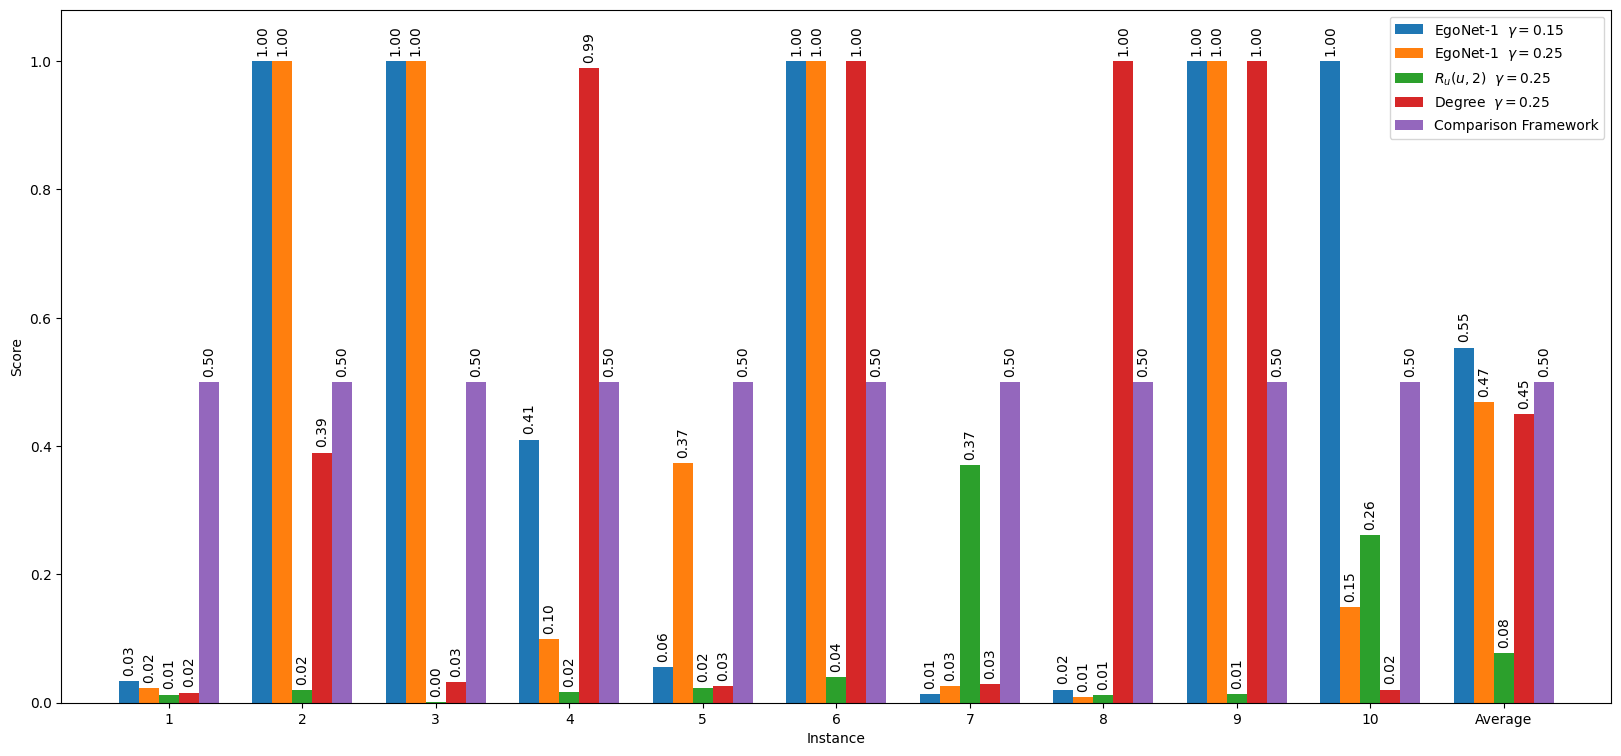

In [22]:
plot_bar_chart(
    graph_params=graph_params_1,
    progress_file_params_list=[
        progress_file_params_1,
        progress_file_params_2,
        progress_file_params_3,
        progress_file_params_4,
    ],
    comparison_result=ComparisonResult(
        name="Comparison Framework",
        result_per_instance=[0.5 for _ in range(N_INSTANCES)]
    ),
    highlighted_properties=["gamma"]
)

Save output? (y/n):  n


Average Scores for Instances - graph with 1024 nodes, removing edge probability 0.1


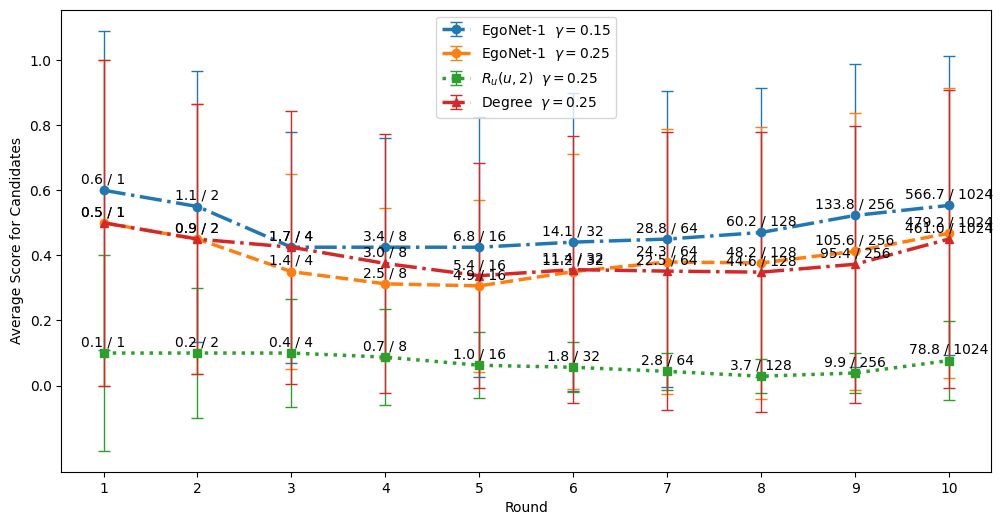

In [23]:
plot_line_chart(
    graph_params=graph_params_1,
    instance_idx=None,
    progress_file_params_list=[
        progress_file_params_1,
        progress_file_params_2,
        progress_file_params_3,
        progress_file_params_4,
    ],
    highlighted_properties=["gamma"]
)

Save output? (y/n):  n


Scores for Instance 1 - graph with 1024 nodes, removing edge probability 0.1


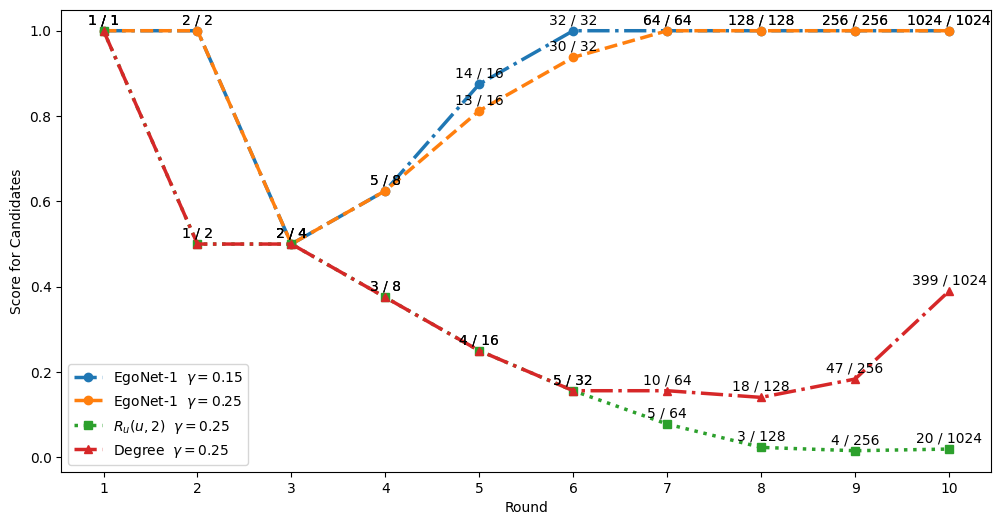

In [24]:
plot_line_chart(
    graph_params=graph_params_1,
    instance_idx=1,
    progress_file_params_list=[
        progress_file_params_1,
        progress_file_params_2,
        progress_file_params_3,
        progress_file_params_4,
    ],
    highlighted_properties=["gamma"]
)